# India Education & Literacy Gap — Exploration

Interactive walkthrough of the analysis, using real 2015-16 UDISE state-level data.

> See `docs/DATA_SOURCES.md` for the source and `docs/METHODOLOGY.md` for what this single-year cross-section can and cannot claim.

In [1]:
import sys
sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from data import load_states
df = load_states()
df.head()

,state,literacy_rate,male_literacy_rate,female_literacy_rate,gender_gap,pupil_teacher_ratio,class10_appeared,class10_passed,class10_pass_rate
0,Jammu And Kashmir,68.74,78.26,58.01,20.3,18.7,120034,78870,65.7
1,Himachal Pradesh,83.78,90.83,76.60,14.2,15.8,132047,99737,75.5
2,Punjab,76.68,81.48,71.34,10.1,19.5,422929,359711,85.1
3,Chandigarh,86.43,90.54,81.38,9.2,20.3,16759,16141,96.3
4,Uttarakhand,79.63,88.33,70.70,17.6,19.7,185631,141466,76.2


In [2]:
# Shape and basic stats
print(df.shape)
df.describe()

(35, 9)


,literacy_rate,male_literacy_rate,female_literacy_rate,gender_gap,pupil_teacher_ratio,class10_appeared,class10_passed,class10_pass_rate
count,35.000000,35.000000,35.000000,35.000000,35.000000,3.500000e+01,3.500000e+01,34.000000
mean,78.648857,85.271714,71.467714,13.802857,25.525714,3.939228e+05,3.152048e+05,79.314706
std,8.121043,6.326527,10.488303,5.740285,15.602043,4.988428e+05,4.183772e+05,12.174044
min,63.820000,73.390000,52.660000,3.400000,10.500000,0.000000e+00,0.000000e+00,54.000000
25%,72.110000,80.520000,62.475000,10.100000,15.950000,1.854050e+04,1.705350e+04,69.650000
50%,79.310000,86.460000,71.340000,13.300000,19.500000,1.320470e+05,9.973700e+04,82.700000
75%,86.305000,90.685000,80.260000,18.300000,29.250000,5.977305e+05,4.890245e+05,88.475000
max,93.910000,96.110000,91.980000,27.900000,70.100000,1.898964e+06,1.578736e+06,98.800000


In [3]:
# Literacy ranking
df.sort_values('literacy_rate', ascending=False).head(10)[['state', 'literacy_rate']]

,state,literacy_rate
31,Kerala,93.91
30,Lakshadweep,92.28
14,Mizoram,91.58
15,Tripura,87.75
29,Goa,87.40
24,Daman & Diu,87.07
33,Puducherry,86.55
3,Chandigarh,86.43
6,Delhi,86.34
34,Andaman & Nicobar Islands,86.27


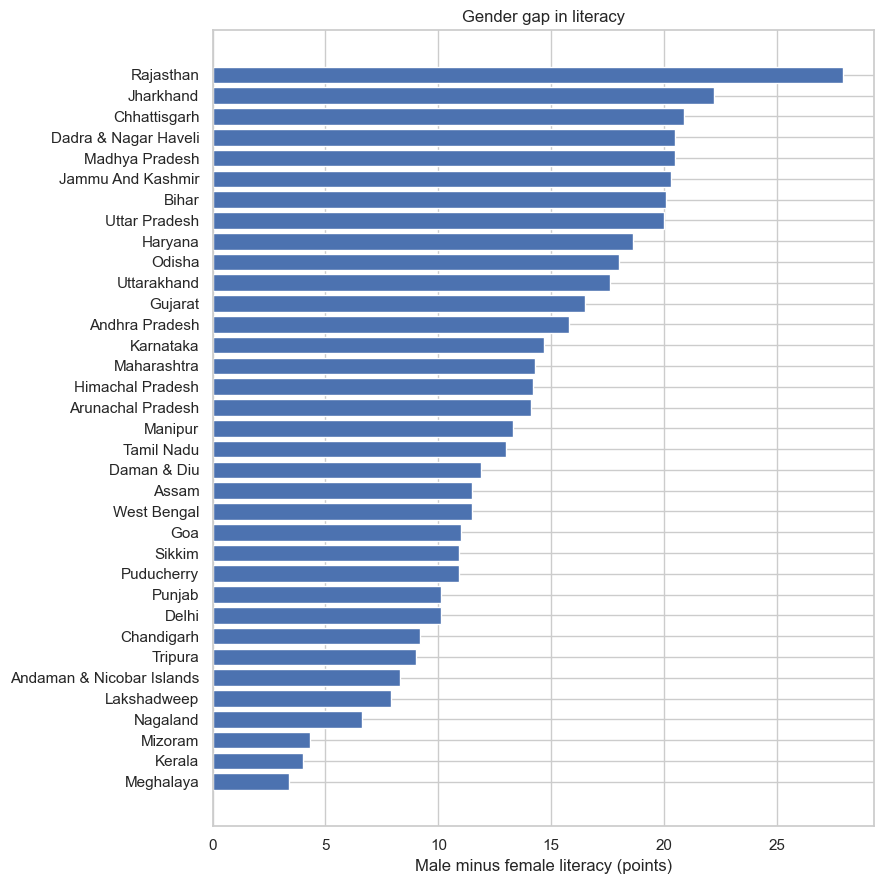

In [4]:
# Gender gap by state
gap = df.sort_values('gender_gap', ascending=False)
plt.figure(figsize=(9, 9))
plt.barh(gap['state'][::-1], gap['gender_gap'][::-1])
plt.xlabel('Male minus female literacy (points)')
plt.title('Gender gap in literacy')
plt.tight_layout()
plt.show()

-0.7356792101288474


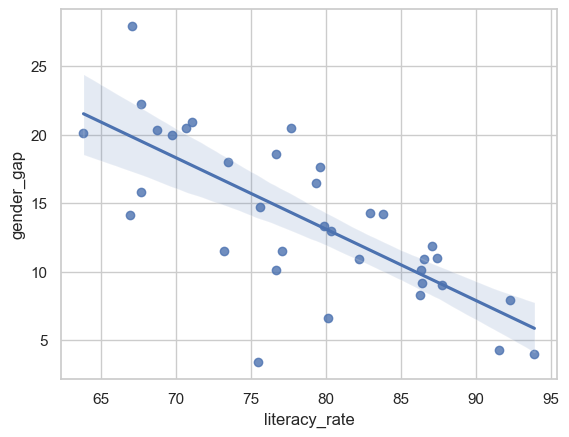

In [5]:
# Correlation: literacy vs gender gap (real, r ~ -0.74)
print(df['literacy_rate'].corr(df['gender_gap']))
sns.regplot(data=df, x='literacy_rate', y='gender_gap')
plt.show()

-0.13089227481658328


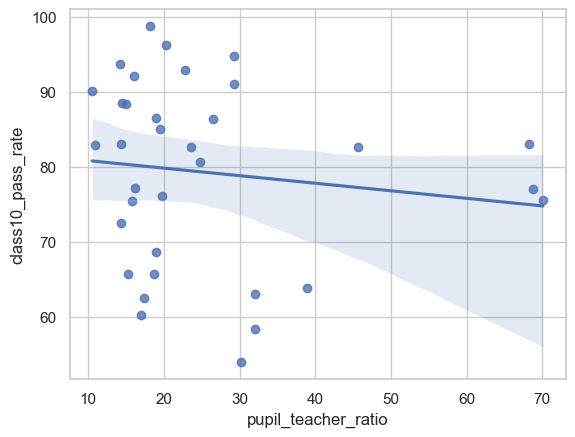

In [6]:
# Correlation: classroom crowding vs Class 10 pass rate (real, r ~ -0.13 -- weak/null)
d = df.dropna(subset=['class10_pass_rate'])
print(d['pupil_teacher_ratio'].corr(d['class10_pass_rate']))
sns.regplot(data=d, x='pupil_teacher_ratio', y='class10_pass_rate')
plt.show()

## Your turn

- Pull a newer UDISE+ release and add a second year to build an honest trend
- Add a district-level breakdown
- Write your own 3 findings below and put them in the README